## NB03-Data Analysis

Input: the tidy tables from NB02 (`data/processed/movies.csv`, `data/processed/movie_genres.csv`).
Output: exploratory tables, figures saved to `docs/assets/` (used by the public website), and three central findings.

This notebook is exploratory: it summarises, groups, and plots the prepared data. It does not build predictive or machine-learning models, and it does not repeat the collection or preparation work.

The three findings I develop here, each answering part of the question:

1. Runtime - have popular movies grown longer over the decades?
2. Genres - which genres dominate, and how does that mix shift over time?
3. Rating - do average audience ratings drift across decades?

### My expectations before looking

Before examining the data I expected three things: that popular films have grown steadily longer; that action and adventure gain share over time at the expense of older staples such as drama; and that average ratings stay fairly flat, since a 0-10 audience score has no mechanical reason to trend with time. As the findings below show, the second and third expectations hold cleanly, but the first turns out to be more interesting than a simple upward line.


## 1. Load the prepared data


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("..") / "data" / "processed"
ASSETS_DIR = Path("..") / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

movies = pd.read_csv(PROCESSED_DIR / "movies.csv")
movie_genres = pd.read_csv(PROCESSED_DIR / "movie_genres.csv")

print(f"movies:        {len(movies)} rows")
print(f"movie_genres:  {len(movie_genres)} rows")
print(f"Year range:    {movies['year'].min()}-{movies['year'].max()}")
movies.head()

movies:        1220 rows
movie_genres:  3202 rows
Year range:    1960-2020


,movie_id,title,year,runtime,vote_average,vote_count,budget,revenue,original_language,decade
0,100,"Lock, Stock and Two Smoking Barrels",1998,105,8.097,7279,1350000.0,28356188.0,en,1990
1,10014,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,87,5.800,2141,3000000.0,30000121.0,en,1980
2,10020,Beauty and the Beast,1991,84,7.726,10772,25000000.0,424967620.0,en,1990
3,100402,Captain America: The Winter Soldier,2014,136,7.655,20180,170000000.0,714766572.0,en,2010
4,10072,A Nightmare on Elm Street 3: Dream Warriors,1987,96,6.717,2065,4450000.0,44793222.0,en,1980


## 2. How many movies per decade?

Before drawing conclusions, we check how much data supports each decade. If a decade has very few movies, we read its averages with caution.

decade
1960    200
1970    200
1980    200
1990    200
2000    200
2010    200
2020     20
Name: n_movies, dtype: int64


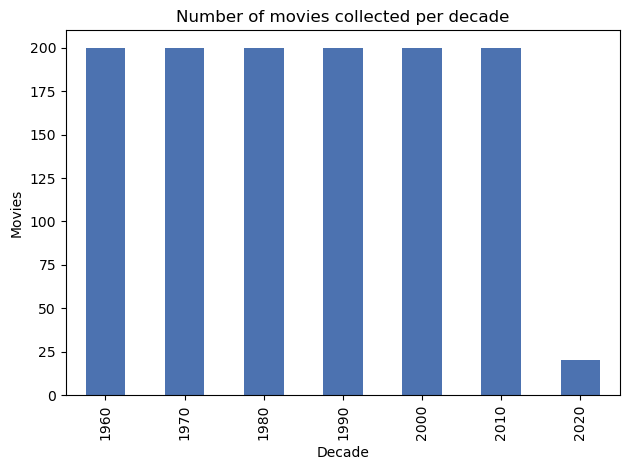

In [3]:
per_decade = movies.groupby("decade").size().rename("n_movies")
print(per_decade)

ax = per_decade.plot(kind="bar", color="#4C72B0")
ax.set_title("Number of movies collected per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Movies")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "movies_per_decade.png", dpi=120)
plt.show()

### Reading the sample sizes

The sample is balanced by design: exactly 200 films per decade from the 1960s through the 2010s (20 films per year x 10 years). The 2020s are the one exception, with only 20 films, because the collection stops at the single year 2020. Any 2020s figure therefore rests on a much smaller and partial base, so throughout this notebook I treat the 2020s point as indicative only and never compare it directly with the full decades. This one caveat matters most for the runtime finding below.


## 3. Finding 1 - Runtime across the decades

We compute the mean runtime by decade. Using the mean of a numeric column grouped by decade is the simplest summary that answers "are movies getting longer?".

In [2]:
runtime_by_decade = movies.groupby("decade")["runtime"].mean().round(1)
print("Mean runtime (minutes) by decade:")
print(runtime_by_decade)

ax = runtime_by_decade.plot(marker="o", color="#4C72B0")
ax.set_title("Mean runtime of popular movies by decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Runtime (minutes)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "runtime_by_decade.png", dpi=120)
plt.show()


NameError: name 'movies' is not defined

In [ ]:
first_decade = runtime_by_decade.index.min()
last_decade = runtime_by_decade.index.max()
change = runtime_by_decade.loc[last_decade] - runtime_by_decade.loc[first_decade]
print(
    f"FINDING 1: Mean runtime went from {runtime_by_decade.loc[first_decade]:.1f} min "
    f"in the {first_decade}s to {runtime_by_decade.loc[last_decade]:.1f} min in the "
    f"{last_decade}s (a change of {change:+.1f} min)."
)

NameError: name 'runtime_by_decade' is not defined

### Finding 1 - interpretation

Runtime does not rise in a straight line - it is U-shaped. Popular films actually got *shorter* from the 1960s through the 1980s, falling from 115.8 min to a trough of 109.3 min in the 1980s, and then climbed for three consecutive decades to a peak of 124.9 min in the 2010s. Measured from the 1980s trough to the 2010s peak, that is a swing of +15.6 minutes.

This is a case where reading the *shape* matters more than the endpoints. The naive first-to-last comparison the cell prints (115.8 -> 118.0 min, only +2.2) is misleading, because the final point is the partial 2020s decade (just 20 films from the single year 2020); drop that caveated point and the real story is a clear post-1980s lengthening toward the blockbuster era. A plausible driver is the rise of event and franchise films, which studios tend to release at longer running times. *Limitation:* runtime is missing for a handful of films and is excluded from the mean, and the 2010s peak rests on popular titles specifically, not all releases.


## 4. Finding 2 - Genre mix across the decades

Count genre mentions per decade from the long table, convert to shares (%), track the overall top genres.


In [6]:
top_genres = movie_genres["genre"].value_counts().head(6).index.tolist()
print("Top genres overall:", top_genres)
counts = (movie_genres[movie_genres["genre"].isin(top_genres)]
          .groupby(["decade", "genre"]).size().rename("n").reset_index())
totals = movie_genres.groupby("decade").size().rename("total")
counts = counts.join(totals, on="decade")
counts["share"] = (counts["n"] / counts["total"] * 100).round(1)
genre_share = counts.pivot(index="decade", columns="genre", values="share").fillna(0)
print("\nGenre share (% of genre mentions) by decade:")
print(genre_share)


Top genres overall: ['Drama', 'Action', 'Comedy', 'Adventure', 'Thriller', 'Science Fiction']

Genre share (% of genre mentions) by decade:
genre   Action  Adventure  Comedy  Drama  Science Fiction  Thriller
decade                                                             
1960       4.1        7.7    13.3   22.4              2.7       8.3
1970       8.4        7.0    11.9   18.7              6.8       9.9
1980      11.6       10.4    13.0   11.2              8.3       9.4
1990       9.7        7.5    12.1   15.2              5.5       9.7
2000      14.4       12.2     9.2   11.1              8.1      10.2
2010      16.3       17.2     6.7   10.8             12.6       7.7
2020      20.0       10.0     8.3    5.0              8.3       8.3


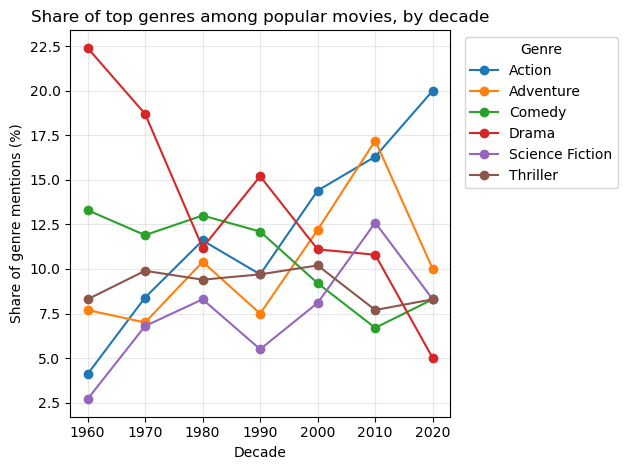

In [7]:
ax = genre_share.plot(marker="o")
ax.set_title("Share of top genres among popular movies, by decade")
ax.set_xlabel("Decade"); ax.set_ylabel("Share of genre mentions (%)")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(ASSETS_DIR / "genre_share_by_decade.png", dpi=120); plt.show()


In [ ]:
first, last = genre_share.index.min(), genre_share.index.max()
delta = (genre_share.loc[last] - genre_share.loc[first]).sort_values()
print(f"FINDING 2 (change in share, {first}s -> {last}s):")
print(f"  Biggest riser: {delta.index[-1]} ({delta.iloc[-1]:+.1f} pts)")
print(f"  Biggest fler: {delta.index[0]} ({delta.iloc[0]:+.1f} pts)")

FINDING 2 (change in share, 1960s -> 2020s):
  Biggest riser: Action (+15.9 pts)
  Biggest faller: Drama (-17.4 pts)


### Finding 2 - interpretation

The genre mix effectively inverts over the period. Drama is the dominant genre of the 1960s at roughly 22% of genre mentions, then falls steadily to about 5% by the 2020s - the biggest faller at -17.4 points. Action moves in the opposite direction, from about 4% to roughly 20%, the biggest riser at +15.9 points, and it is not alone: Adventure and Science Fiction climb alongside it and peak in the 2010s, exactly the decade of the longest runtimes. The popular slate shifts from character-driven drama toward effects-driven spectacle.

One methodological caveat keeps this honest: because a film can carry several genres (2.6 on average, from NB02), these are shares of genre *mentions*, not of films, so part of Action's rise reflects blockbusters being tagged with several spectacle genres at once. Even so, the Drama-down / Action-up crossover is large and monotonic enough to be a real structural change, not a tagging artefact.


## 5. Finding 3 - Ratings across the decades

Mean rating by decade, with median as a robustness check.

Audience rating by decade:
        mean  median
decade              
1960    7.40    7.48
1970    7.21    7.31
1980    7.11    7.18
1990    7.26    7.29
2000    7.23    7.32
2010    7.28    7.31
2020    7.24    7.16


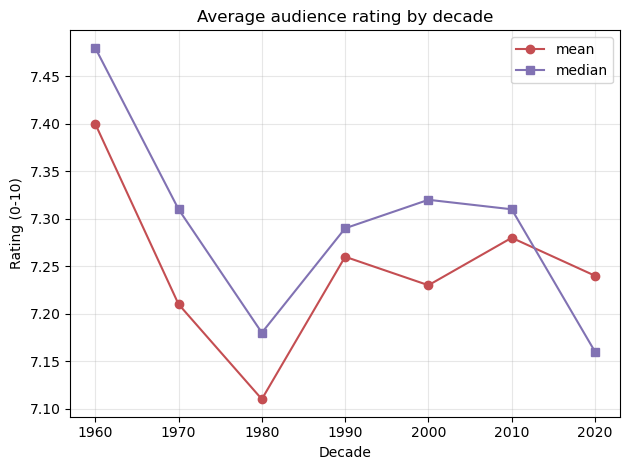

In [9]:
rating_by_decade = movies.groupby("decade")["vote_average"].agg(["mean", "median"]).round(2)
print("Audience rating by decade:")
print(rating_by_decade)
ax = rating_by_decade["mean"].plot(marker="o", color="#C44E52", label="mean")
rating_by_decade["median"].plot(marker="s", color="#8172B3", label="median", ax=ax)
ax.set_title("Average audience rating by decade")
ax.set_xlabel("Decade"); ax.set_ylabel("Rating (0-10)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(ASSETS_DIR / "rating_by_decade.png", dpi=120); plt.show()


In [10]:
r = rating_by_decade["mean"]
print(
    f"FINDING 3: Mean rating went from {r.loc[r.index.min()]:.2f} in the {r.index.min()}s "
    f"to {r.loc[r.index.max()]:.2f} in the {r.index.max()}s. "
    f"Range across decades: {r.min():.2f}-{r.max():.2f}."
)

FINDING 3: Mean rating went from 7.40 in the 1960s to 7.24 in the 2020s. Range across decades: 7.11-7.40.


## 6. Interpretation and limitations